# Microglia WGCNA: First Exploratory Analysis

In this notebook, I run a first-pass weighted gene co-expression network analysis (WGCNA) on **microglia pseudobulk expression** derived from my labelled single-nucleus RNA-seq dataset.

I use **PyWGCNA** here so that I can stay inside my current Python workflow while following the same high-level logic as a standard WGCNA analysis:

1. build donor-level microglia pseudobulk expression
2. filter genes to a stable and informative set
3. run an exploratory co-expression network analysis
4. identify disease-associated modules
5. inspect hub genes and functional enrichment
6. compare module genes back to my microglial differential expression results

Because I only have a modest number of donor-level samples, I treat this as an **exploratory, hypothesis-generating analysis** rather than a definitive network study.


## 1. Imports And Setup

I start by loading the saved labelled pseudobulk object and defining an output directory dedicated to this first WGCNA analysis.


In [1]:
from pathlib import Path
import sys
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

from PyWGCNA import WGCNA

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results'
FIG_DIR = RESULTS_DIR / 'figures'
WGCNA_DIR = RESULTS_DIR / 'wgcna_microglia'
WGCNA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

WGCNA_NAME = 'microglia_first_pass'


## 2. Load The Labelled Pseudobulk Source Object

I use the saved `adata_merged_pb_exc_focus.h5ad` checkpoint because it already contains the raw-count pseudobulk source matrix and the Harmony-derived broad cell-type labels.


In [2]:
adata_merged_pb = sc.read_h5ad(
    DATA_DIR / 'processed' / 'merged' / 'adata_merged_pb_exc_focus.h5ad'
)

print(adata_merged_pb.shape)
print('Has counts layer:', 'counts' in adata_merged_pb.layers)
print('Has cell_class_major_harmony:', 'cell_class_major_harmony' in adata_merged_pb.obs.columns)
print(adata_merged_pb.obs['cell_class_major_harmony'].value_counts(dropna=False))


(89819, 61552)
Has counts layer: True
Has cell_class_major_harmony: True
cell_class_major_harmony
Unknown                33403
Excitatory_neurons     19806
Microglia              17981
Astrocytes              6821
Inhibitory_neurons      5955
OPCs                    4284
NaN                      936
Endothelial              363
Vascular_mural_like      270
Name: count, dtype: int64


## 3. Define A Reusable Pseudobulk Helper

I keep the pseudobulk logic explicit here so that the notebook is self-contained. I aggregate **raw counts** by sample within a chosen cell class.


In [3]:
def pseudobulk_by_sample(
    adata,
    group_value,
    groupby_col='cell_class_major_harmony',
    min_cells_per_sample=20,
    layer='counts',
):
    # I subset to one biological group first.
    sub = adata[adata.obs[groupby_col] == group_value].copy()
    if sub.n_obs == 0:
        raise ValueError(f'No cells found for {groupby_col}={group_value!r}.')

    # I keep only donors with enough cells to support a stable pseudobulk profile.
    cell_counts = sub.obs['sample'].value_counts()
    keep_samples = cell_counts[cell_counts >= min_cells_per_sample].index.tolist()
    if not keep_samples:
        raise ValueError(
            f'No samples retained for {groupby_col}={group_value!r} '
            f'with min_cells_per_sample={min_cells_per_sample}.'
        )

    sub = sub[sub.obs['sample'].isin(keep_samples)].copy()
    sample_order = sorted(sub.obs['sample'].astype(str).unique())

    pb_counts = []
    pb_meta = []

    for sample_id in sample_order:
        ss = sub[sub.obs['sample'].astype(str) == sample_id]
        matrix = ss.layers[layer] if layer in ss.layers else ss.X
        vec = np.asarray(matrix.sum(axis=0)).ravel()
        pb_counts.append(vec)
        pb_meta.append({
            'sample': sample_id,
            'condition': ss.obs['condition'].astype(str).iloc[0],
            'group': group_value,
            'groupby_col': groupby_col,
            'n_cells': ss.n_obs,
        })

    counts_df = pd.DataFrame(pb_counts, index=sample_order, columns=sub.var_names)
    meta_df = pd.DataFrame(pb_meta).set_index('sample')
    return counts_df, meta_df


## 4. Load Saved Microglia Pseudobulk Expression

I load the donor-level microglia pseudobulk counts and metadata that I previously exported from `10_Peudobulk.ipynb`. This keeps the WGCNA notebook modular and avoids rebuilding the same pseudobulk matrix again.


In [4]:
counts_df = pd.read_csv(
    RESULTS_DIR / "pseudobulk" / "Microglia_counts.csv",
    index_col=0,
)

meta_df = pd.read_csv(
    RESULTS_DIR / "pseudobulk" / "Microglia_meta.csv",
    index_col=0,
)

print(counts_df.shape)
display(meta_df)
print(meta_df["condition"].value_counts())

(12, 61552)


,condition,group,groupby_col,n_cells
sample,,,,
GSM5292143,sALS,Microglia,cell_class_major_harmony,1426
GSM5292144,sALS,Microglia,cell_class_major_harmony,2669
GSM5292145,sALS,Microglia,cell_class_major_harmony,1448
GSM5292146,c9ALS,Microglia,cell_class_major_harmony,1502
GSM5292147,c9ALS,Microglia,cell_class_major_harmony,1638
GSM5292148,sALS,Microglia,cell_class_major_harmony,2169
GSM5292156,c9ALS,Microglia,cell_class_major_harmony,1353
GSM5292157,c9ALS,Microglia,cell_class_major_harmony,1279
GSM5292174,Control,Microglia,cell_class_major_harmony,1191


condition
sALS       4
c9ALS      4
Control    4
Name: count, dtype: int64


In [5]:
counts_df.to_csv(WGCNA_DIR / 'microglia_pseudobulk_counts_raw.csv')
meta_df.to_csv(WGCNA_DIR / 'microglia_pseudobulk_metadata.csv')


## 5. Filter And Transform Genes For Network Analysis

I do **not** run WGCNA on all genes. Instead, I:

- remove genes with extremely sparse counts across donors
- transform counts to log-CPM
- keep the most variable genes for a first-pass network analysis

This is especially important here because the donor-level sample size is modest.


In [7]:
MIN_COUNT = 10
MIN_SAMPLES = 4
TOP_N_VARIABLE_GENES = 5000

# I first remove genes that are barely detected across donors.
keep_detected = (counts_df >= MIN_COUNT).sum(axis=0) >= MIN_SAMPLES
counts_detected = counts_df.loc[:, keep_detected].copy()

# I then compute log-CPM so the network is built on transformed donor-level expression.
libsize = counts_detected.sum(axis=1)
log_cpm = np.log1p(counts_detected.div(libsize, axis=0) * 1e6)

gene_medians = log_cpm.median(axis=0)
gene_mad = log_cpm.sub(gene_medians, axis=1).abs().median(axis=0).sort_values(ascending=False)
selected_genes = gene_mad.head(min(TOP_N_VARIABLE_GENES, gene_mad.shape[0])).index
expr_wgcna = log_cpm.loc[:, selected_genes].copy()

print('Raw pseudobulk matrix:', counts_df.shape)
print('After detection filter:', counts_detected.shape)
print('Final WGCNA matrix:', expr_wgcna.shape)


Raw pseudobulk matrix: (12, 61552)
After detection filter: (12, 19020)
Final WGCNA matrix: (12, 5000)


In [8]:
expr_wgcna.to_csv(WGCNA_DIR / 'microglia_logCPM_for_wgcna.csv')


## 6. Create The PyWGCNA Input Object

PyWGCNA expects an expression matrix with **samples as rows** and **genes as columns**, plus sample metadata and gene metadata. I create that object explicitly so I can inspect every step.


In [9]:
sample_info = meta_df.copy()
sample_info['condition'] = sample_info['condition'].astype(str)

# I keep gene identifiers simple here because my pseudobulk columns are already gene symbols / IDs.
gene_info = pd.DataFrame(index=expr_wgcna.columns)
gene_info['gene_id'] = gene_info.index.astype(str)
gene_info['gene_name'] = gene_info.index.astype(str)

wgcna_ad = ad.AnnData(
    X=expr_wgcna.values,
    obs=sample_info.loc[expr_wgcna.index].copy(),
    var=gene_info.loc[expr_wgcna.columns].copy(),
)

print(wgcna_ad)
display(wgcna_ad.obs.head())
display(wgcna_ad.var.head())


AnnData object with n_obs × n_vars = 12 × 5000
    obs: 'condition', 'group', 'groupby_col', 'n_cells'
    var: 'gene_id', 'gene_name'


,condition,group,groupby_col,n_cells
GSM5292143,sALS,Microglia,cell_class_major_harmony,1426
GSM5292144,sALS,Microglia,cell_class_major_harmony,2669
GSM5292145,sALS,Microglia,cell_class_major_harmony,1448
GSM5292146,c9ALS,Microglia,cell_class_major_harmony,1502
GSM5292147,c9ALS,Microglia,cell_class_major_harmony,1638


,gene_id,gene_name
ENSG00000233359,ENSG00000233359,ENSG00000233359
CRH,CRH,CRH
HAMP,HAMP,HAMP
IL1B,IL1B,IL1B
VGF,VGF,VGF


## 7. Initialise The PyWGCNA Analysis

I use a relatively conservative, first-pass set of parameters. Because this is an exploratory donor-level network with a limited number of samples, I keep the settings interpretable rather than aggressive.


In [10]:
wgcna = WGCNA(
    name=WGCNA_NAME,
    species='Human',
    anndata=wgcna_ad,
    outputPath=str(WGCNA_DIR) + '/',
    save=True,
    figureType='png',
    TPMcutoff=0,
    cut=float('inf'),
    powers=list(range(1, 11)) + list(range(12, 21, 2)),
    RsquaredCut=0.80,
    MeanCut=100,
    networkType='signed hybrid',
    TOMType='signed',
    minModuleSize=30,
    MEDissThres=0.2,
)


Saving data to be True, checking requirements ...
Figure directory does not exist!
Creating figure directory!


## 8. Preprocess Samples And Run Module Detection

This follows the main PyWGCNA workflow:

- preprocess samples / genes
- choose a soft threshold
- build the co-expression network
- identify modules


Pre-processing...
	Detecting genes and samples with too many missing values...
	Done pre-processing..

Run WGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  5000
    Power  SFT.R.sq     slope truncated R.sq      mean(k)    median(k)  \
0       1   0.16053  0.345671       0.810034  1866.043577  2223.702071   
1       2  0.002917  0.025701       0.662447  1237.561422  1382.638816   
2       3  0.185377 -0.182135         0.5354   905.079325   907.644178   
3       4  0.523028 -0.320758       0.678095    700.22307   625.526646   
4       5   0.71725 -0.420269       0.774281   562.217123   445.590848   
5       6  0.811683 -0.505626       0.809776   463.569911   325.146906   
6       7  0.828632 -0.580237       0.800185   389.997541   246.737638   
7       8  0.844641 -0.644472       0.808912   333.338603   191.953685   
8       9  0.842607 -0.703114       0.801208   288.593665   152.507951   
9      10  0.850302  -0.75003       0.808076   252.532

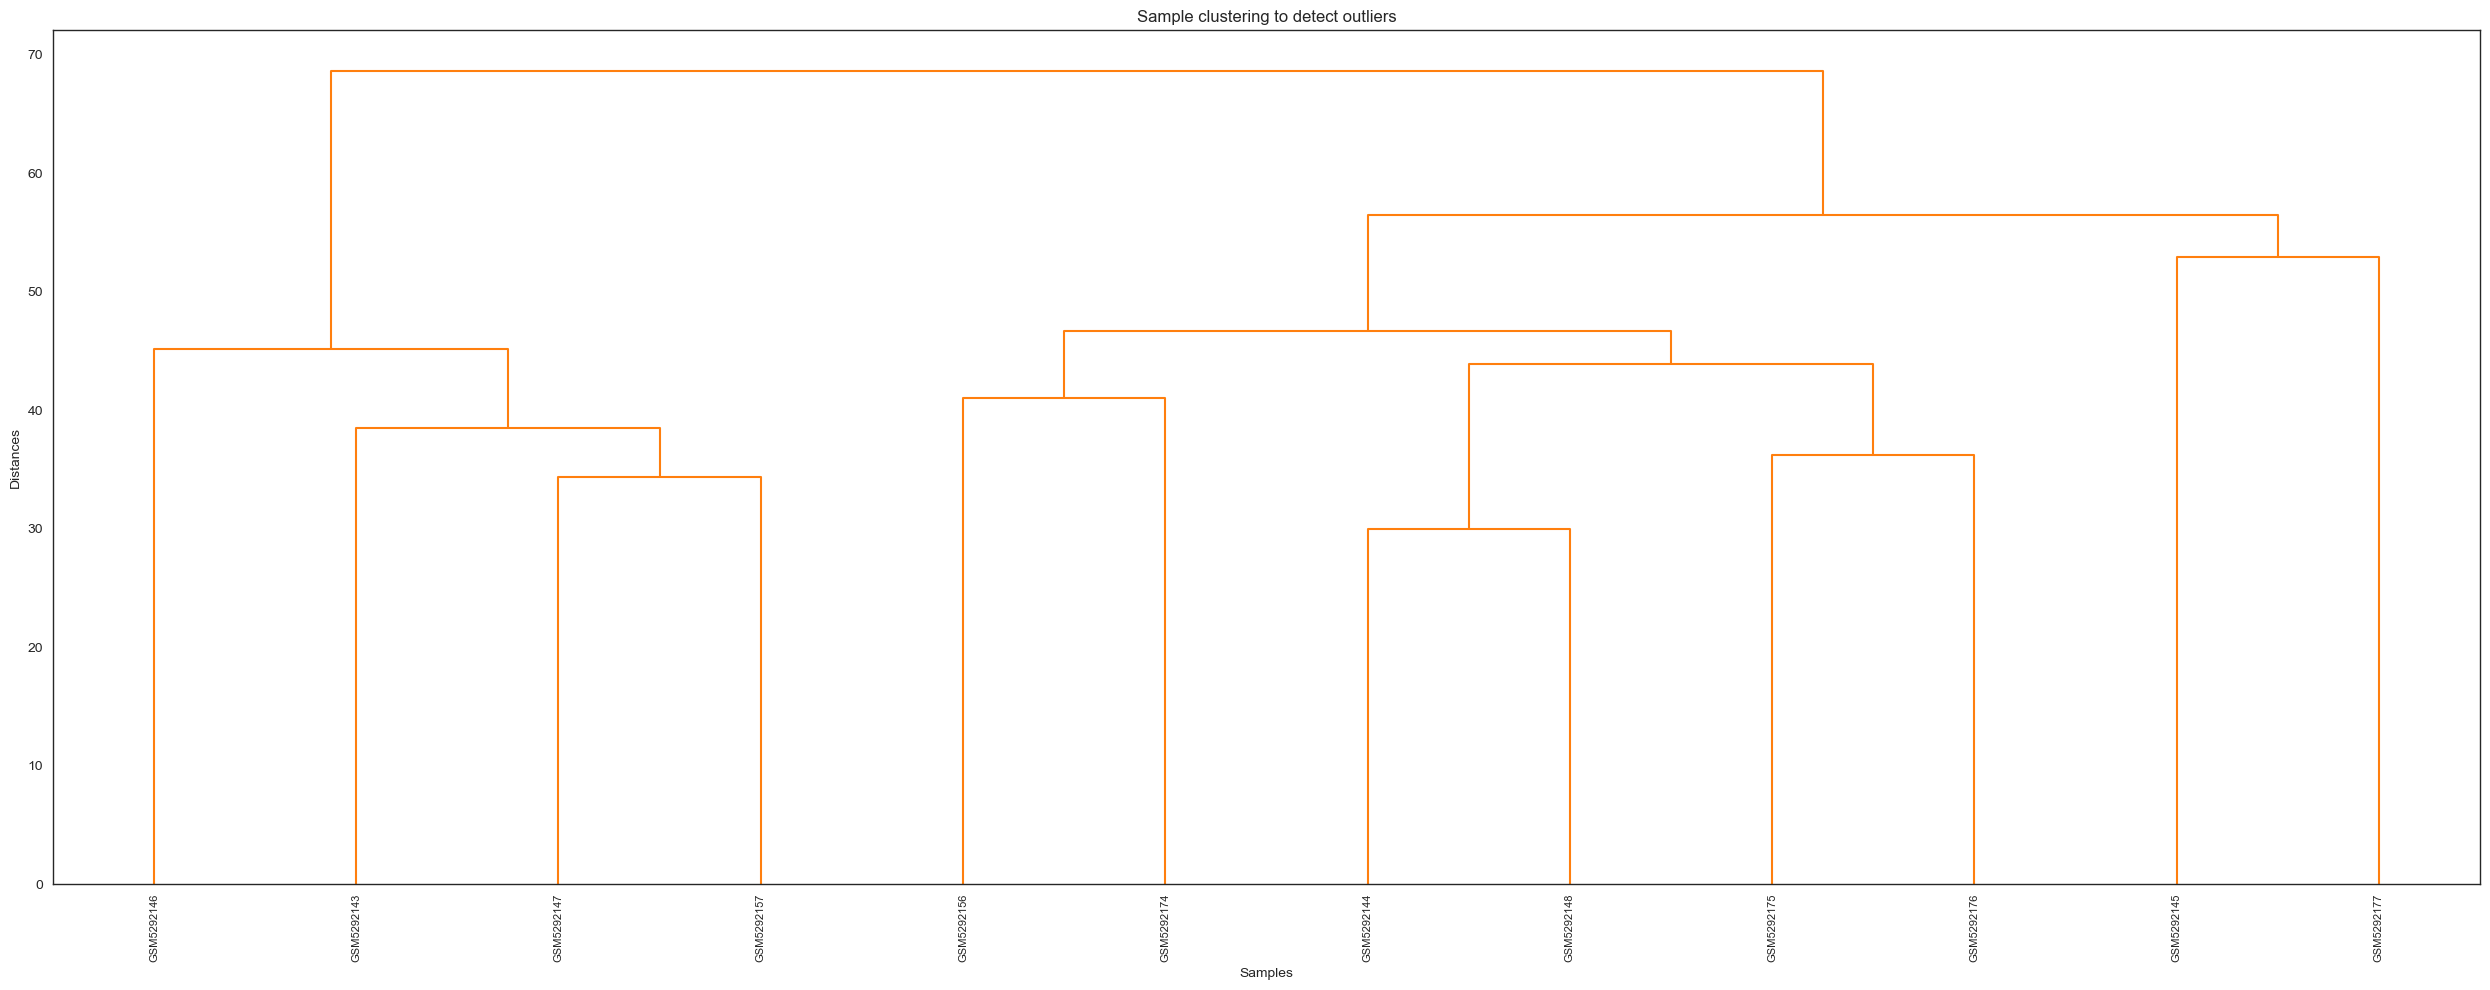

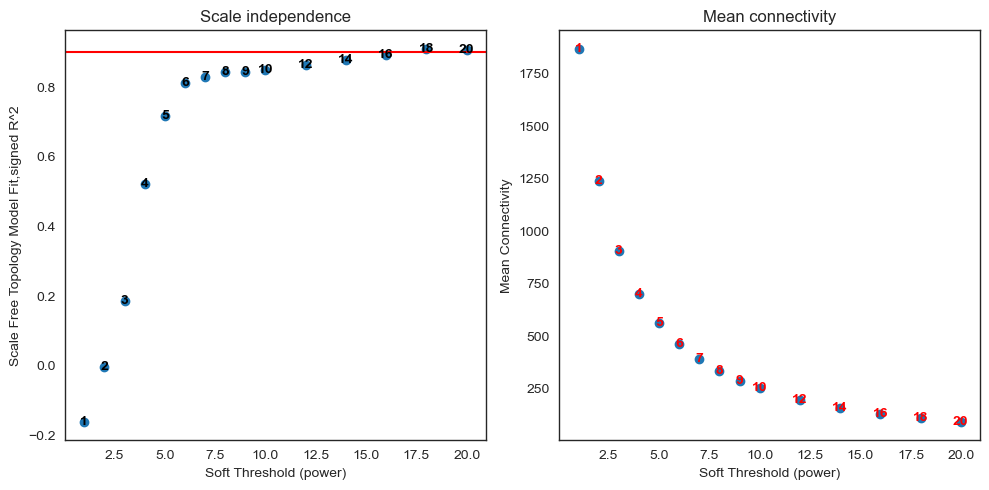

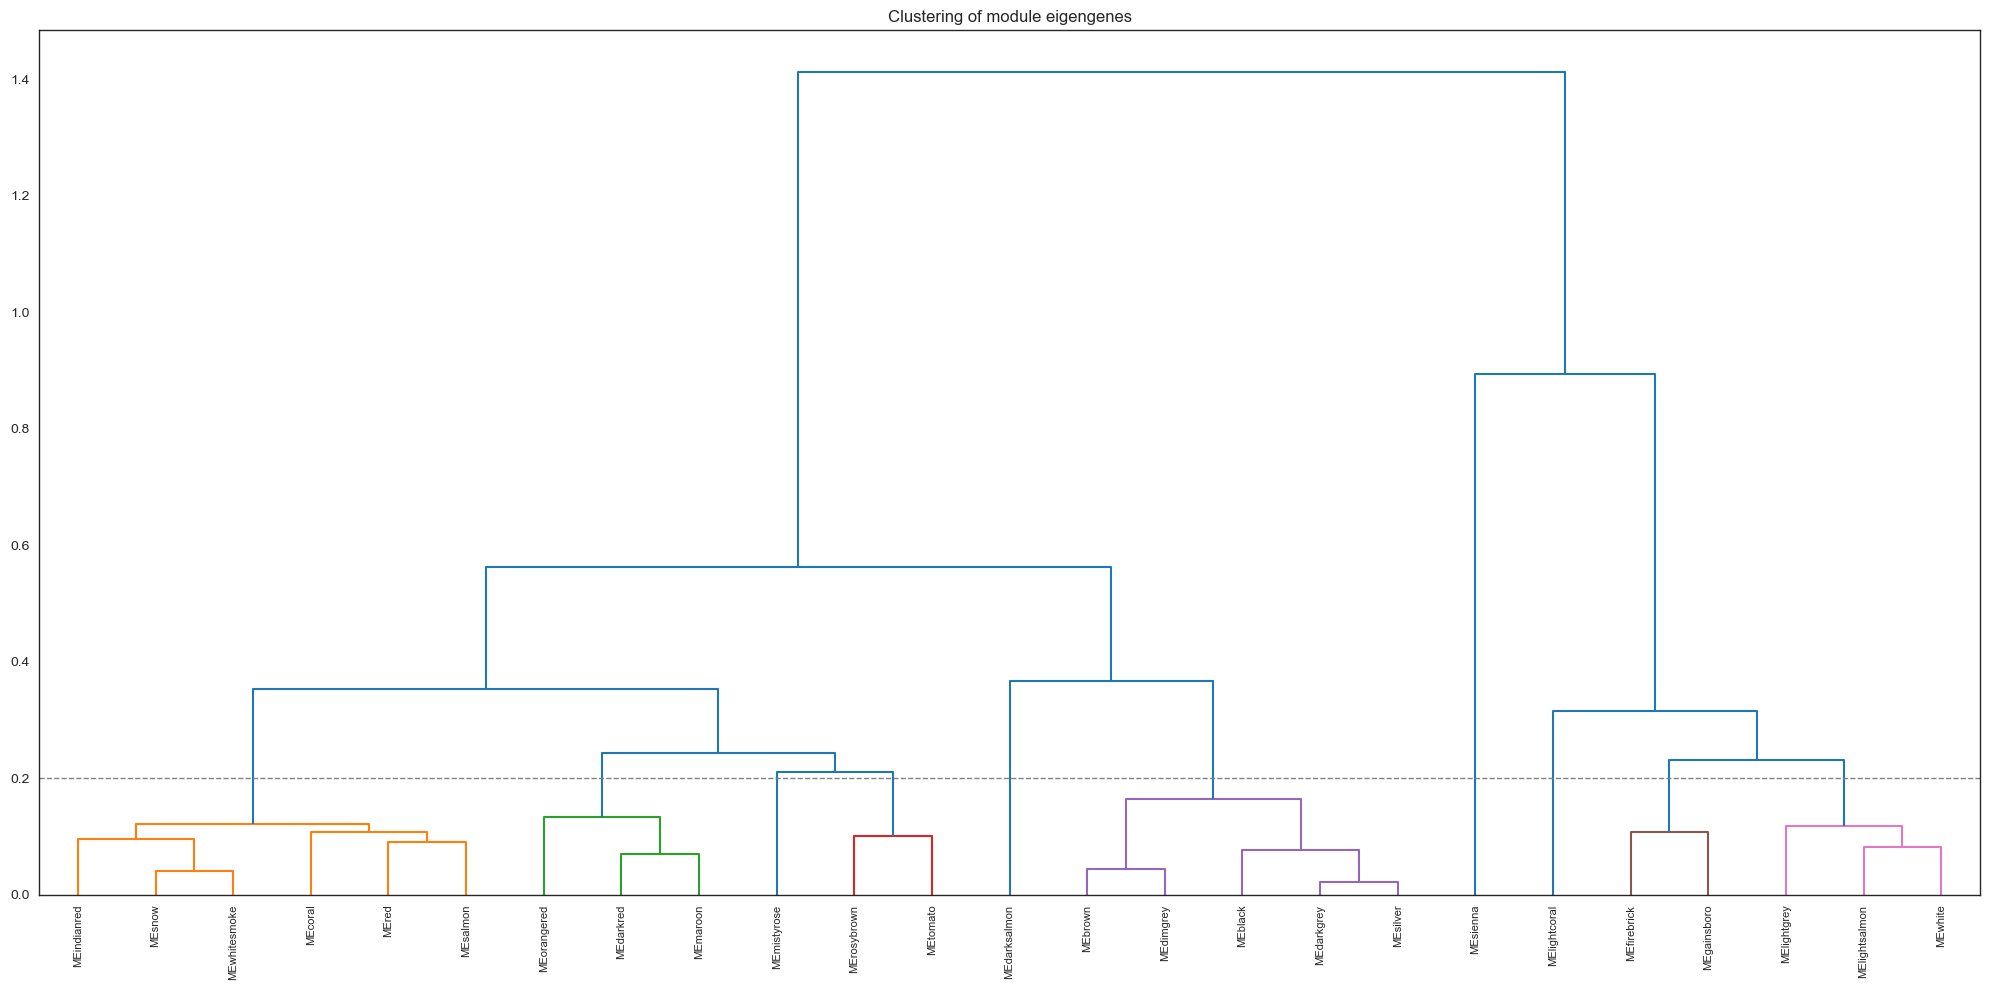

In [11]:
wgcna.preprocess(show=True)
wgcna.findModules(
    kwargs_function={
        'cutreeHybrid': {
            'deepSplit': 2,
            'pamRespectsDendro': False,
        }
    }
)

wgcna.saveWGCNA()


## 9. Inspect Module Sizes

I first check how many modules were detected and how many genes ended up in each module.


,module,n_genes
0,black,2907
1,coral,801
2,firebrick,493
3,sienna,435
4,darkred,141
5,darksalmon,97
6,mistyrose,71
7,lightcoral,55


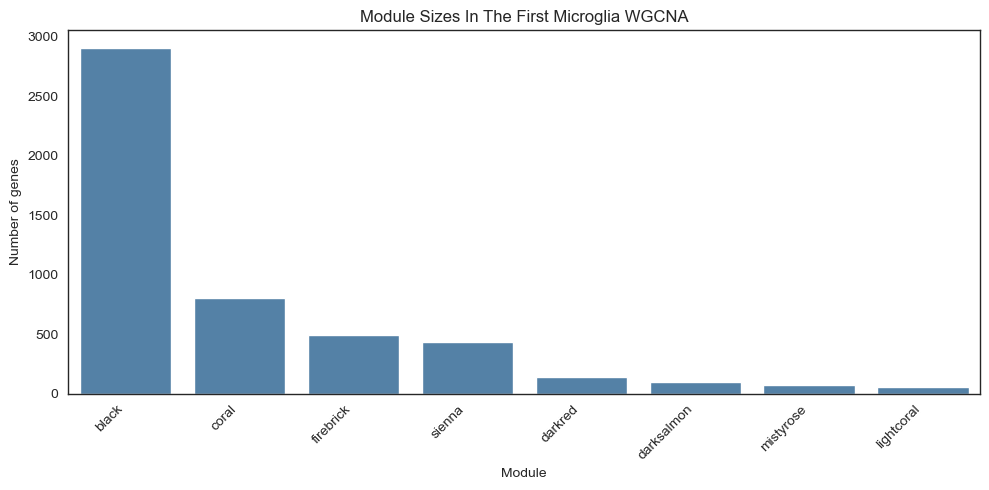

In [12]:
module_sizes = wgcna.datExpr.var['moduleColors'].value_counts().rename_axis('module').reset_index(name='n_genes')
module_sizes = module_sizes.sort_values('n_genes', ascending=False)
display(module_sizes)

plt.figure(figsize=(10, 5))
sns.barplot(data=module_sizes, x='module', y='n_genes', color='steelblue')
plt.title('Module Sizes In The First Microglia WGCNA')
plt.xlabel('Module')
plt.ylabel('Number of genes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 10. Relate Modules To Disease Status

I now test whether module eigengenes correlate with the donor-level metadata I provided. Here, the key trait is `condition`, and I also keep `n_cells` so I can see whether any module is mainly tracking pseudobulk cell yield.


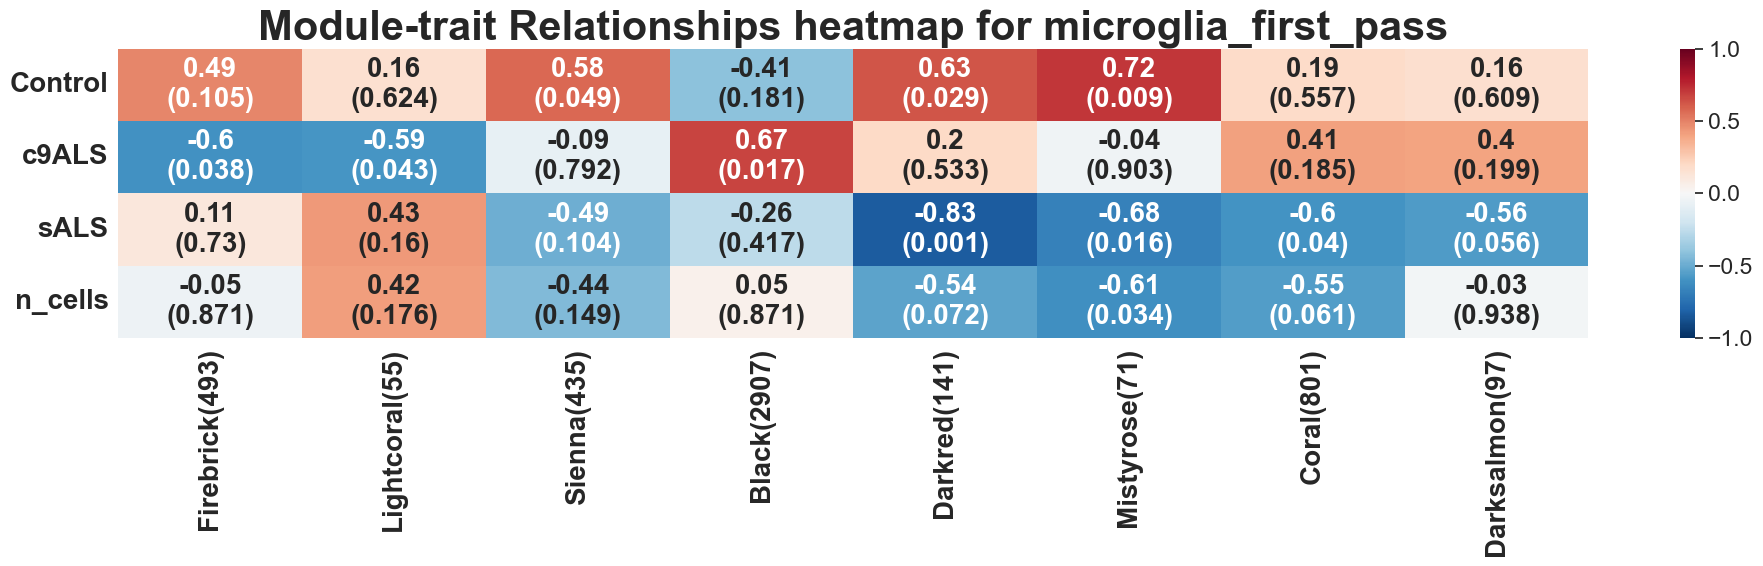

In [13]:
condition_palette = {
    'Control': '#4C78A8',
    'sALS': '#F58518',
    'c9ALS': '#54A24B',
}

wgcna.setMetadataColor('condition', condition_palette)
wgcna.module_trait_relationships_heatmap(
    metaData=wgcna.datExpr.obs.columns.tolist(),
    show=True,
    file_name=f'{WGCNA_NAME}_module_trait_relationships',
)


In [14]:
trait_results = (
    wgcna.moduleTraitCor.stack().rename('correlation').to_frame()
    .join(wgcna.moduleTraitPvalue.stack().rename('pvalue'))
    .reset_index()
    .rename(columns={'level_0': 'module', 'level_1': 'trait'})
)
trait_results['abs_correlation'] = trait_results['correlation'].abs()
trait_results = trait_results.sort_values(['pvalue', 'abs_correlation'], ascending=[True, False])

display(trait_results.head(20))


,module,trait,correlation,pvalue,abs_correlation
18,MEdarkred,sALS,-0.828467,0.000870,0.828467
20,MEmistyrose,Control,0.716396,0.008764,0.716396
22,MEmistyrose,sALS,-0.677010,0.015593,0.677010
13,MEblack,c9ALS,0.672333,0.016608,0.672333
16,MEdarkred,Control,0.628173,0.028713,0.628173
23,MEmistyrose,n_cells,-0.611813,0.034498,0.611813
1,MEfirebrick,c9ALS,-0.602595,0.038102,0.602595
26,MEcoral,sALS,-0.598787,0.039666,0.598787
5,MElightcoral,c9ALS,-0.590381,0.043279,0.590381
8,MEsienna,Control,0.577352,0.049331,0.577352


## 11. Select Disease-Relevant Modules For Follow-Up

For a first pass, I focus on modules that show the strongest relationship with the disease labels. If nothing passes a strict threshold, I still keep the top few modules for exploratory follow-up.


In [15]:
condition_traits = sorted(meta_df['condition'].astype(str).unique().tolist())
trait_hits = trait_results[trait_results['trait'].isin(condition_traits)].copy()
trait_hits = trait_hits.sort_values(['pvalue', 'abs_correlation'], ascending=[True, False])

display(trait_hits.head(20))

interesting_modules = (
    trait_hits.loc[trait_hits['pvalue'] < 0.10, 'module']
    .str.replace('^ME', '', regex=True)
    .drop_duplicates()
    .tolist()
)

if len(interesting_modules) == 0:
    interesting_modules = (
        trait_hits['module']
        .str.replace('^ME', '', regex=True)
        .drop_duplicates()
        .head(3)
        .tolist()
    )

print('Modules selected for follow-up:', interesting_modules)


,module,trait,correlation,pvalue,abs_correlation
18,MEdarkred,sALS,-0.828467,0.000870,0.828467
20,MEmistyrose,Control,0.716396,0.008764,0.716396
22,MEmistyrose,sALS,-0.677010,0.015593,0.677010
13,MEblack,c9ALS,0.672333,0.016608,0.672333
16,MEdarkred,Control,0.628173,0.028713,0.628173
1,MEfirebrick,c9ALS,-0.602595,0.038102,0.602595
26,MEcoral,sALS,-0.598787,0.039666,0.598787
5,MElightcoral,c9ALS,-0.590381,0.043279,0.590381
8,MEsienna,Control,0.577352,0.049331,0.577352
30,MEdarksalmon,sALS,-0.563733,0.056269,0.563733


Modules selected for follow-up: ['darkred', 'mistyrose', 'black', 'firebrick', 'coral', 'lightcoral', 'sienna', 'darksalmon']


## 12. Plot Eigengenes For The Most Relevant Modules

I plot module eigengenes by condition so I can see whether the module-level effect is broad and consistent across donors.


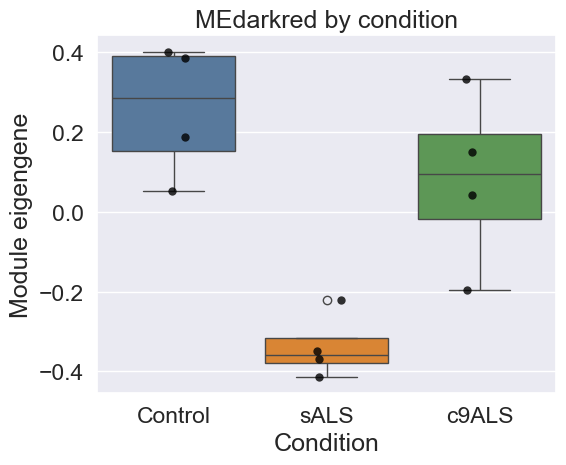

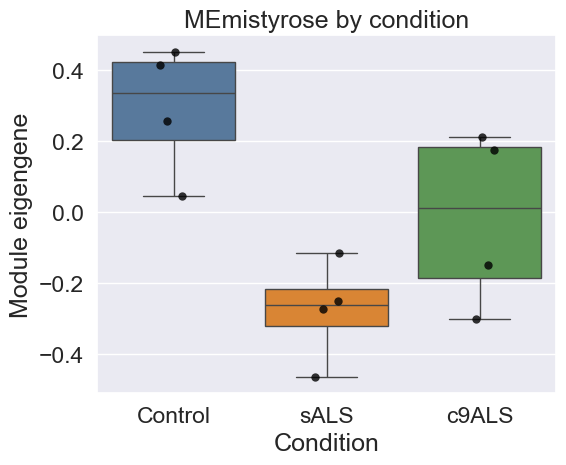

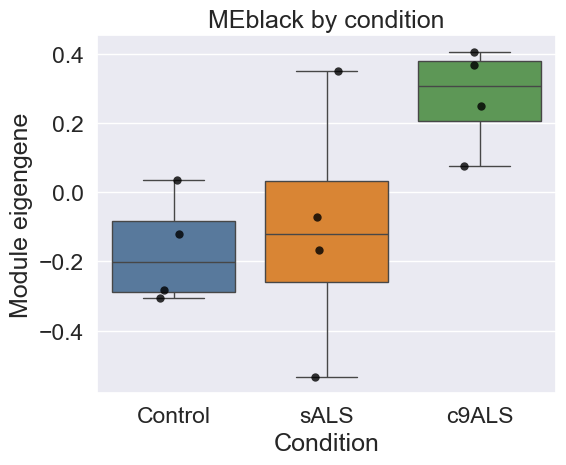

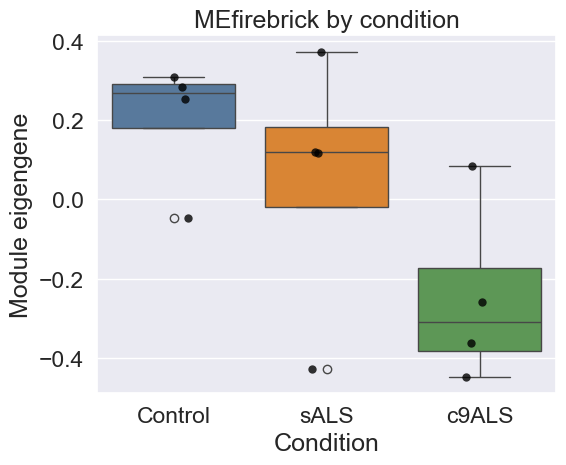

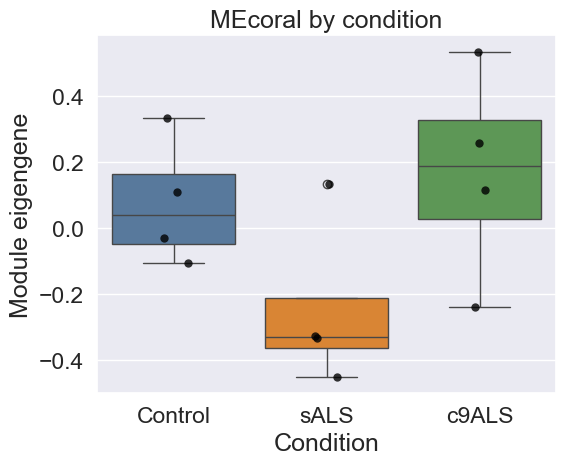

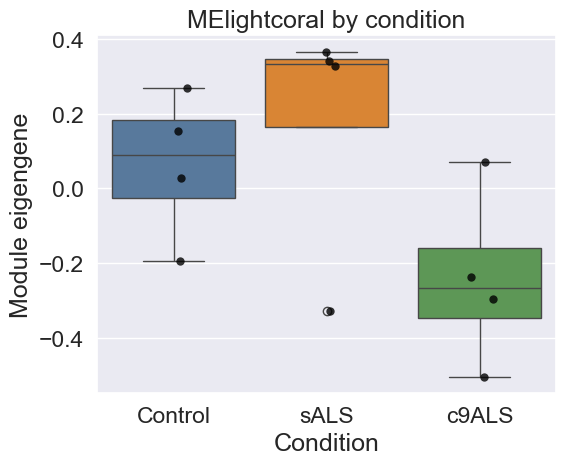

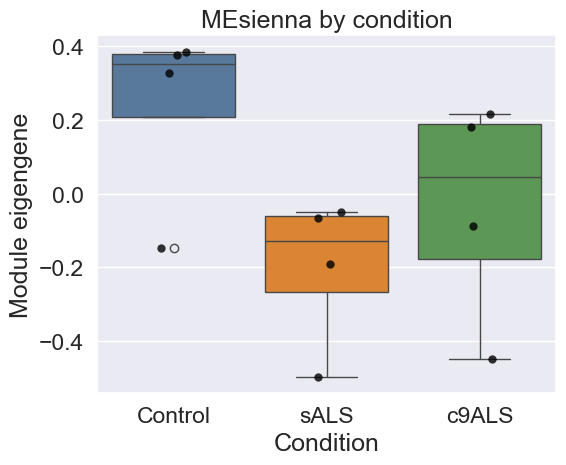

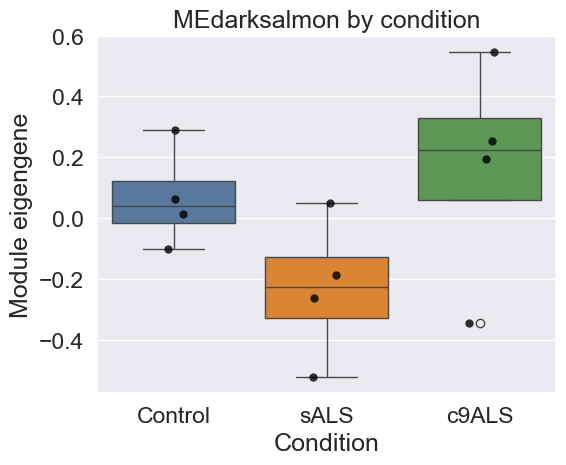

In [16]:
module_eigengenes = wgcna.datME.copy()
module_eigengenes['condition'] = wgcna.datExpr.obs['condition'].values
module_eigengenes['n_cells'] = wgcna.datExpr.obs['n_cells'].values
module_eigengenes.index.name = 'sample'

for module in interesting_modules:
    me_col = f'ME{module}'
    if me_col not in module_eigengenes.columns:
        continue

    plt.figure(figsize=(6, 5))
    sns.boxplot(
        data=module_eigengenes,
        x='condition',
        y=me_col,
        order=['Control', 'sALS', 'c9ALS'],
        palette=condition_palette,
    )
    sns.stripplot(
        data=module_eigengenes,
        x='condition',
        y=me_col,
        order=['Control', 'sALS', 'c9ALS'],
        color='black',
        size=6,
        alpha=0.8,
    )
    plt.title(f'{me_col} by condition')
    plt.xlabel('Condition')
    plt.ylabel('Module eigengene')
    plt.tight_layout()
    plt.show()


## 13. Inspect Hub Genes In The Modules Of Interest

Hub genes give me a first biological handle on what each disease-associated module might represent.


In [18]:
hub_gene_tables = {}

for module in interesting_modules:
    hub_gene_tables[module] = wgcna.top_n_hub_genes(moduleName=module, n=15)
    print(f"\nTop hub genes for module: {module}")
    display(hub_gene_tables[module])


calculating adjacency matrix ...
	Done..


Top hub genes for module: darkred


,connectivity,gene_id,gene_name,dynamicColors,moduleColors,moduleLabels
TRIM28,6.229873,TRIM28,TRIM28,darkred,darkred,2
LCAT,5.937992,LCAT,LCAT,darkred,darkred,2
PAXX,5.489146,PAXX,PAXX,darkred,darkred,2
PFN1,5.215397,PFN1,PFN1,darkred,darkred,2
ARHGDIA,5.146667,ARHGDIA,ARHGDIA,darkred,darkred,2
RPL3P4,5.080673,RPL3P4,RPL3P4,darkred,darkred,2
EIF3G,5.040484,EIF3G,EIF3G,darkred,darkred,2
LMF2,4.930154,LMF2,LMF2,darkred,darkred,2
TSSC4,4.875059,TSSC4,TSSC4,darkred,darkred,2
RPL10AP6,4.861867,RPL10AP6,RPL10AP6,darkred,darkred,2


calculating adjacency matrix ...
	Done..


Top hub genes for module: mistyrose


,connectivity,gene_id,gene_name,dynamicColors,moduleColors,moduleLabels
LAPTM5,4.019276,LAPTM5,LAPTM5,mistyrose,mistyrose,6
LTBR,3.925545,LTBR,LTBR,mistyrose,mistyrose,6
NABP1,3.879582,NABP1,NABP1,mistyrose,mistyrose,6
SP100,3.852806,SP100,SP100,mistyrose,mistyrose,6
SPI1,3.759481,SPI1,SPI1,mistyrose,mistyrose,6
PPP1R18,3.700808,PPP1R18,PPP1R18,mistyrose,mistyrose,6
UNC93B1,3.225008,UNC93B1,UNC93B1,mistyrose,mistyrose,6
ICAM1,3.194237,ICAM1,ICAM1,mistyrose,mistyrose,6
PGGHG,2.986135,PGGHG,PGGHG,mistyrose,mistyrose,6
TNFRSF10A,2.984884,TNFRSF10A,TNFRSF10A,mistyrose,mistyrose,6


calculating adjacency matrix ...
	Done..


Top hub genes for module: black


...

,connectivity,gene_id,gene_name,dynamicColors,moduleColors,moduleLabels
WDFY4,5.438027,WDFY4,WDFY4,lightcoral,lightcoral,5
C1QTNF3-AMACR,5.079121,C1QTNF3-AMACR,C1QTNF3-AMACR,lightcoral,lightcoral,5
ADCY7,4.930716,ADCY7,ADCY7,lightcoral,lightcoral,5
CD33,4.714278,CD33,CD33,lightcoral,lightcoral,5
BEST1,4.518423,BEST1,BEST1,lightcoral,lightcoral,5
ENSG00000287706,4.461596,ENSG00000287706,ENSG00000287706,lightcoral,lightcoral,5
MYO5B,4.306070,MYO5B,MYO5B,lightcoral,lightcoral,5
ZBTB37,4.118111,ZBTB37,ZBTB37,lightcoral,lightcoral,5
E2F3,3.913374,E2F3,E2F3,lightcoral,lightcoral,5
TRPM6,3.865386,TRPM6,TRPM6,lightcoral,lightcoral,5


calculating adjacency matrix ...
	Done..


Top hub genes for module: sienna


,connectivity,gene_id,gene_name,dynamicColors,moduleColors,moduleLabels
PRKY,2.096092,PRKY,PRKY,sienna,sienna,7
ANOS2P,2.090393,ANOS2P,ANOS2P,sienna,sienna,7
PCDH11Y,1.812574,PCDH11Y,PCDH11Y,sienna,sienna,7
SLC22A2,1.725851,SLC22A2,SLC22A2,sienna,sienna,7
GIPC1,1.720339,GIPC1,GIPC1,sienna,sienna,7
SLC26A3,1.713396,SLC26A3,SLC26A3,sienna,sienna,7
ENSG00000266385,1.653953,ENSG00000266385,ENSG00000266385,sienna,sienna,7
N6AMT1,1.634718,N6AMT1,N6AMT1,sienna,sienna,7
RABGEF1,1.620174,RABGEF1,RABGEF1,sienna,sienna,7
ADAT1,1.593746,ADAT1,ADAT1,sienna,sienna,7


calculating adjacency matrix ...
	Done..


Top hub genes for module: darksalmon


,connectivity,gene_id,gene_name,dynamicColors,moduleColors,moduleLabels
ENSG00000287580,8.187647,ENSG00000287580,ENSG00000287580,darksalmon,darksalmon,3
ENSG00000285117,7.202514,ENSG00000285117,ENSG00000285117,darksalmon,darksalmon,3
ENSG00000255580,6.962998,ENSG00000255580,ENSG00000255580,darksalmon,darksalmon,3
ENSG00000236986,6.488125,ENSG00000236986,ENSG00000236986,darksalmon,darksalmon,3
PCDH9-AS1,6.273819,PCDH9-AS1,PCDH9-AS1,darksalmon,darksalmon,3
ANKUB1,6.131389,ANKUB1,ANKUB1,darksalmon,darksalmon,3
SUCLA2P3,5.841325,SUCLA2P3,SUCLA2P3,darksalmon,darksalmon,3
BIRC6-AS2,5.703470,BIRC6-AS2,BIRC6-AS2,darksalmon,darksalmon,3
PRKCA-AS1,5.563875,PRKCA-AS1,PRKCA-AS1,darksalmon,darksalmon,3
ENSG00000286808,5.526076,ENSG00000286808,ENSG00000286808,darksalmon,darksalmon,3


## 14. Compare WGCNA Modules With My Microglia DE Results

I also compare module genes back to the microglia differential expression signatures that I already generated. This helps me connect coordinated modules with the single-gene results.


In [19]:
de_comparisons = ['Control_vs_sALS', 'Control_vs_c9ALS', 'sALS_vs_c9ALS']

de_gene_sets = {}
for comparison in de_comparisons:
    de_path = RESULTS_DIR / 'de_pseudobulk_broad' / f'Microglia_{comparison}.csv'
    de_df = pd.read_csv(de_path)
    de_df = de_df.dropna(subset=['padj', 'log2FoldChange']).copy()
    de_gene_sets[comparison] = set(
        de_df.loc[
            (de_df['padj'] < 0.10) & (de_df['log2FoldChange'].abs() > 0.25),
            'gene'
        ].astype(str)
    )

overlap_rows = []
for module in interesting_modules:
    module_genes = set(
        wgcna.datExpr.var.index[wgcna.datExpr.var['moduleColors'] == module].astype(str)
    )
    for comparison, sig_genes in de_gene_sets.items():
        overlap_rows.append({
            'module': module,
            'comparison': comparison,
            'module_size': len(module_genes),
            'n_sig_de': len(sig_genes),
            'overlap_n': len(module_genes & sig_genes),
            'overlap_genes': ', '.join(sorted(module_genes & sig_genes)[:20]),
        })

overlap_df = pd.DataFrame(overlap_rows)
display(overlap_df)


,module,comparison,module_size,n_sig_de,overlap_n,overlap_genes
0,darkred,Control_vs_sALS,141,704,66,"A2MP1, ACTB, AP1G2-AS1, APOC1, ARHGDIA, BAX, C..."
1,darkred,Control_vs_c9ALS,141,3196,15,"A2MP1, ACTB, ARHGDIA, C1orf56, EFCAB10, EIF5A,..."
2,darkred,sALS_vs_c9ALS,141,394,5,"PTGER4P2-CDK2AP2P2, RABAC1, RPS15P4, RUFY1-AS1..."
3,mistyrose,Control_vs_sALS,71,704,27,"ADGRG5, BCL3, C5AR1, ENSG00000278996, FCGR1A, ..."
4,mistyrose,Control_vs_c9ALS,71,3196,23,"BCL3, C2CD2, C5AR1, FCGR1A, FCGR1B, GTF2H2B, H..."
5,mistyrose,sALS_vs_c9ALS,71,394,2,"ENSG00000249001, VN1R83P"
6,black,Control_vs_sALS,2907,704,68,"AGGF1, ALG1L12P, ARL17B, AURKAIP1, B3GAT1-DT, ..."
7,black,Control_vs_c9ALS,2907,3196,1612,"ABCD2, ABCG8, ABHD8, ABLIM1, ABLIM2, ACHE, ACO..."
8,black,sALS_vs_c9ALS,2907,394,56,"ACP2, AP1S1, B4GAT1, C1QTNF4, CCDC107, CCDC85B..."
9,firebrick,Control_vs_sALS,493,704,22,"ABHD17A, ABHD17AP3, ADAP1, ASIC3, ATF4, DVL1, ..."


## 15. Run First-Pass Functional Enrichment For Modules Of Interest

PyWGCNA can run enrichment analysis directly. These calls rely on online resources, so they require an internet connection when I execute them.

For a first pass, I focus on:

- GO biological process enrichment
- Reactome pathway enrichment

This is the step where I can ask whether disease-associated modules point towards pathways such as immune activation, lysosomal biology, oxidative phosphorylation, or proteostasis.


In [20]:
# I leave this cell ready to run when I want online enrichment.
for module in interesting_modules:
    print(f'Running enrichment for module: {module}')
    wgcna.functional_enrichment_analysis(
        type='GO',
        moduleName=module,
        sets=['GO_Biological_Process_2021'],
        p_value=0.05,
        file_name=f'{module}_GO_BP',
    )
    wgcna.functional_enrichment_analysis(
        type='REACTOME',
        moduleName=module,
        p_value=0.05,
        file_name=f'{module}_Reactome',
    )


Running enrichment for module: darkred
GO directory does not exist!
Creating microglia_first_pass_GO directory!
No enrich terms when cutoff = 0.05 in module darkred
REACTOME directory does not exist!
Creating microglia_first_pass_REACTOME directory!
Status code returned a value of 404
54 out of 141 genes (identifiers) in the sample were found in Reactome.
1599 pathways were hit by at least one of them, which 1 of them have p-value less than 0.05.
Report was saved /Users/wangj/Documents/Computational_Biology/Projects/C9_Multiomics/results/wgcna_microglia/figures/microglia_first_pass_REACTOME/darkred_Reactome.png!
For more information please visit https://reactome.org/PathwayBrowser/#/DTAB=AN&ANALYSIS=MjAyNjA0MDkwMDMxMTdfNjA1NA%3D%3D
Running enrichment for module: mistyrose
No enrich terms when cutoff = 0.05 in module mistyrose
Status code returned a value of 404
33 out of 71 genes (identifiers) in the sample were found in Reactome.
1106 pathways were hit by at least one of them, which 1

## 16. Notes For Interpretation

At this stage, I want to ask four main questions:

1. which module eigengenes separate `sALS`, `c9ALS`, and `Control` microglia?
2. do the strongest modules recapitulate the biology I already saw in my DE analysis?
3. do the hub genes in those modules make biological sense for microglial activation or dysfunction?
4. do enrichment results highlight autophagy-lysosomal, inflammatory, phagocytic, oxidative phosphorylation, or proteostasis pathways?

If this first pass is promising, the next step would be to refine the analysis further by:

- tuning gene filtering thresholds
- checking module robustness
- comparing module membership with my autophagy-focused gene list
- adding a targeted GSEA follow-up for modules of interest
